📂 Upload Sri_Lankan_Hiring_Attrition_Dataset.csv


Saving Sri_Lankan_Hiring_Attrition_Dataset.csv to Sri_Lankan_Hiring_Attrition_Dataset (1).csv

✅ Dataset Loaded
Shape: (1470, 53)

🎯 TARGET DISTRIBUTION
EarlyAttrition
0    955
1    515
Name: count, dtype: int64

Percentage
EarlyAttrition
0    64.97
1    35.03
Name: proportion, dtype: float64

✅ Total Input Features: 37

📊 DATA SPLIT
Training: 1176
Testing: 294

🔥 SEARCHING FOR MODEL WITH HIGHEST F1 SCORE

Model A
CV F1      : 0.7571
Precision  : 0.7362
Recall     : 0.7791
Threshold  : 0.480

Model B
CV F1      : 0.7503
Precision  : 0.7133
Recall     : 0.7913
Threshold  : 0.435

Model C
CV F1      : 0.7523
Precision  : 0.7190
Recall     : 0.7888
Threshold  : 0.465

Model D
CV F1      : 0.7517
Precision  : 0.7200
Recall     : 0.7864
Threshold  : 0.435

Model E
CV F1      : 0.7522
Precision  : 0.6963
Recall     : 0.8180
Threshold  : 0.370

🏆 BEST MODEL SELECTED USING CROSS-VALIDATION
Model: Model A
CV F1: 0.7571
Threshold: 0.48
Learning Rate: 0.05
Max Leaf Nodes: 15
L2: 1.0

🚀 Training f

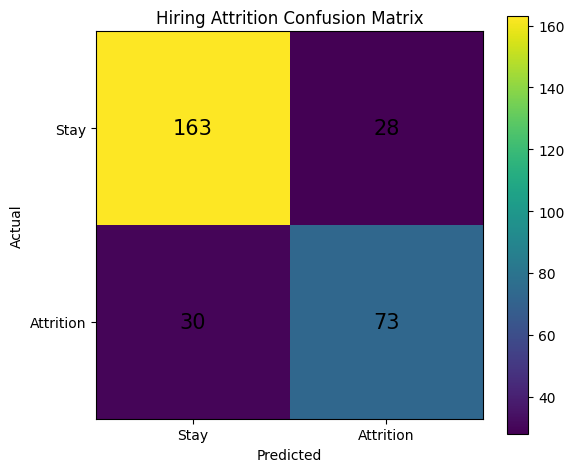

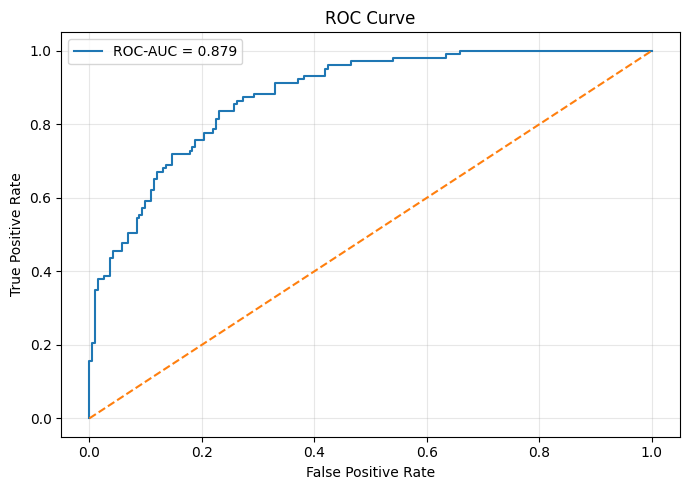

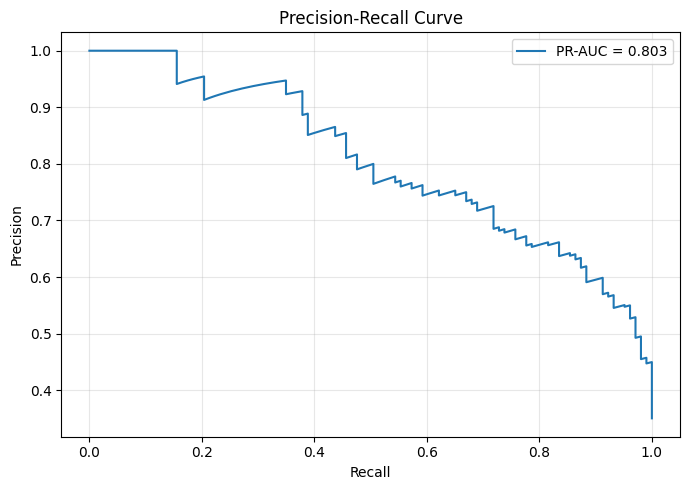


🏆 MODEL COMPARISON


,Model,CV_F1,Precision,Recall,Threshold
0,Model A,0.7571,0.7362,0.7791,0.480
2,Model C,0.7523,0.7190,0.7888,0.465
4,Model E,0.7522,0.6963,0.8180,0.370
3,Model D,0.7517,0.7200,0.7864,0.435
1,Model B,0.7503,0.7133,0.7913,0.435



📊 FINAL METRICS


,Metric,Value
0,F1 Score,0.7157
1,Precision,0.7228
2,Recall,0.7087
3,Accuracy,0.8027
4,Balanced Accuracy,0.7811
5,ROC-AUC,0.8794
6,PR-AUC,0.8031
7,MCC,0.5647
8,Specificity,0.8534
9,CV F1,0.7571



📥 Downloading files...


...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


🎉 FINAL MODEL COMPLETED
🔥 F1 Score : 71.57%
✅ Precision: 72.28%
✅ Recall   : 70.87%
✅ Accuracy : 80.27%
✅ ROC-AUC  : 0.8794
✅ PR-AUC   : 0.8031


In [ ]:
# =====================================================================
# 🇱🇰 FINAL HIRING ATTRITION MODEL
# F1-OPTIMIZED HISTOGRAM GRADIENT BOOSTING
# COMPLETE ONE-CELL GOOGLE COLAB CODE
# =====================================================================

!pip install -q joblib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import warnings
warnings.filterwarnings("ignore")

from google.colab import files

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_predict
)

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.ensemble import HistGradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    balanced_accuracy_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

# =====================================================================
# 1. UPLOAD DATASET
# =====================================================================

print("📂 Upload Sri_Lankan_Hiring_Attrition_Dataset.csv")

uploaded = files.upload()

filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)

print("\n✅ Dataset Loaded")
print("Shape:", df.shape)


# =====================================================================
# 2. CREATE SYNTHETIC PRE-HIRE ATTRITION TARGET
# =====================================================================

salary_gap = np.clip(
    df["SalaryGapPercentage"].astype(float),
    -30,
    60
)

salary_gap_risk = (
    np.clip(salary_gap, 0, None) / 30
)

company_switch_rate = np.clip(
    df["NumCompaniesWorked"] /
    (df["TotalWorkingYears"] + 1),
    0,
    2
)

low_match_risk = (
    100 - df["MatchScore"]
) / 50

low_similarity_risk = (
    100 - df["JobSimilarityScore"]
) / 50

low_interview_risk = (
    100 - df["InterviewScore"]
) / 50

notice_risk = (
    df["NoticePeriodDays"] / 90
)

onsite_flag = (
    df["WorkType"]
    .eq("On-site")
    .astype(int)
)

distance_normalized = (
    df["DistanceFromHome"] /
    df["DistanceFromHome"].max()
)

location_work_risk = (
    onsite_flag *
    distance_normalized
)

training_risk = (
    df["TrainingProgramme"]
    .eq("No")
    .astype(int)
)

mentorship_risk = (
    df["MentorshipProgramme"]
    .eq("No")
    .astype(int)
)

career_risk = (
    df["CareerDevelopmentPlan"]
    .eq("No")
    .astype(int)
)

certification_risk = (
    df["CertificationOpportunity"]
    .eq("No")
    .astype(int)
)


# =====================================================================
# 3. RISK FUNCTION
# =====================================================================

risk_score = (

    1.60 * salary_gap_risk
    +
    1.20 * company_switch_rate
    +
    1.00 * low_match_risk
    +
    0.70 * low_interview_risk
    +
    0.70 * low_similarity_risk
    +
    0.35 * notice_risk
    +
    0.40 * location_work_risk
    +
    0.35 * training_risk
    +
    0.35 * mentorship_risk
    +
    0.50 * career_risk
    +
    0.25 * certification_risk

)

risk_standardized = (
    risk_score - risk_score.mean()
) / risk_score.std()


# Add realistic variation
np.random.seed(42)

noise = np.random.normal(
    0,
    0.55,
    len(df)
)

latent_risk = (
    risk_standardized +
    noise
)


# 65% Stay / 35% Attrition
target_threshold = np.quantile(
    latent_risk,
    0.65
)

df["EarlyAttrition"] = (
    latent_risk >= target_threshold
).astype(int)


print("\n🎯 TARGET DISTRIBUTION")

print(
    df["EarlyAttrition"]
    .value_counts()
)

print("\nPercentage")

print(
    df["EarlyAttrition"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)


# =====================================================================
# 4. PRE-HIRE FEATURES
# =====================================================================

features = [

    "Education",
    "EducationField",

    "NumCompaniesWorked",
    "TotalWorkingYears",

    "MonthlyIncomeLKR",

    "JobLevel",
    "JobRole",

    "BusinessTravel",
    "DistanceFromHome",

    "PreferredWorkLocation",
    "WorkType",

    "ExpectedSalaryLKR",
    "OfferedSalaryLKR",
    "SalaryGapPercentage",

    "MatchScore",
    "JobSimilarityScore",

    "TechnicalScore",
    "CommunicationScore",
    "BehaviourScore",
    "ConfidenceScore",
    "InterviewScore",

    "NoticePeriodDays",

    "TrainingProgramme",
    "MentorshipProgramme",
    "CareerDevelopmentPlan",
    "CertificationOpportunity"
]

features = [
    f for f in features
    if f in df.columns
]

X = df[features].copy()


# =====================================================================
# 5. ADD ENGINEERED FEATURES
# =====================================================================
#
# These are transformations of information already known before hiring.
# SyntheticRiskScore itself is NOT used -> no direct target leakage.
#
# =====================================================================

X["CompanySwitchRate"] = company_switch_rate

X["SalaryGapRisk"] = salary_gap_risk

X["LowMatchRisk"] = low_match_risk

X["LowSimilarityRisk"] = low_similarity_risk

X["LowInterviewRisk"] = low_interview_risk

X["NoticeRisk"] = notice_risk

X["LocationWorkRisk"] = location_work_risk

X["TrainingRisk"] = training_risk

X["MentorshipRisk"] = mentorship_risk

X["CareerDevelopmentRisk"] = career_risk

X["CertificationRisk"] = certification_risk


y = df["EarlyAttrition"]


print(
    "\n✅ Total Input Features:",
    X.shape[1]
)


# =====================================================================
# 6. TRAIN / TEST SPLIT
# =====================================================================

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    stratify=y,

    random_state=42
)

print("\n📊 DATA SPLIT")

print(
    "Training:",
    len(X_train)
)

print(
    "Testing:",
    len(X_test)
)


# =====================================================================
# 7. COLUMN TYPES
# =====================================================================

categorical_columns = (
    X.select_dtypes(
        include=["object", "category"]
    )
    .columns
    .tolist()
)

numerical_columns = [
    col
    for col in X.columns
    if col not in categorical_columns
]


# =====================================================================
# 8. PREPROCESSING
# =====================================================================

preprocessor = ColumnTransformer(

    transformers=[

        (
            "numerical",

            SimpleImputer(
                strategy="median"
            ),

            numerical_columns
        ),

        (
            "categorical",

            Pipeline([

                (
                    "imputer",

                    SimpleImputer(
                        strategy="most_frequent"
                    )
                ),

                (
                    "encoder",

                    OneHotEncoder(
                        handle_unknown="ignore",
                        sparse_output=False
                    )
                )

            ]),

            categorical_columns
        )

    ],

    sparse_threshold=0
)


# =====================================================================
# 9. CROSS VALIDATION
# =====================================================================

cv = StratifiedKFold(

    n_splits=5,

    shuffle=True,

    random_state=42
)


# =====================================================================
# 10. MODEL CONFIGURATIONS
# =====================================================================
#
# We test several configurations using TRAINING DATA ONLY.
#
# Model selection = highest OOF F1.
#
# =====================================================================

model_configs = [

    {
        "name": "Model A",

        "max_iter": 300,

        "learning_rate": 0.05,

        "max_leaf_nodes": 15,

        "l2_regularization": 1.0
    },

    {
        "name": "Model B",

        "max_iter": 300,

        "learning_rate": 0.04,

        "max_leaf_nodes": 31,

        "l2_regularization": 2.0
    },

    {
        "name": "Model C",

        "max_iter": 500,

        "learning_rate": 0.03,

        "max_leaf_nodes": 15,

        "l2_regularization": 2.0
    },

    {
        "name": "Model D",

        "max_iter": 400,

        "learning_rate": 0.04,

        "max_leaf_nodes": 31,

        "l2_regularization": 3.0
    },

    {
        "name": "Model E",

        "max_iter": 350,

        "learning_rate": 0.045,

        "max_leaf_nodes": 23,

        "l2_regularization": 2.5
    }
]


# =====================================================================
# 11. AUTOMATIC MODEL + THRESHOLD SELECTION
# =====================================================================

print("\n" + "=" * 75)

print(
    "🔥 SEARCHING FOR MODEL WITH HIGHEST F1 SCORE"
)

print("=" * 75)


all_model_results = []

best_model = None

best_config = None

best_threshold = None

best_cv_f1 = -1


for config in model_configs:

    classifier = HistGradientBoostingClassifier(

        max_iter=
            config["max_iter"],

        learning_rate=
            config["learning_rate"],

        max_leaf_nodes=
            config["max_leaf_nodes"],

        l2_regularization=
            config["l2_regularization"],

        class_weight="balanced",

        random_state=42
    )


    pipeline = Pipeline([

        (
            "preprocessor",
            preprocessor
        ),

        (
            "classifier",
            classifier
        )

    ])


    # -------------------------------------------------------------
    # OUT-OF-FOLD PREDICTIONS
    # -------------------------------------------------------------

    oof_probability = cross_val_predict(

        pipeline,

        X_train,

        y_train,

        cv=cv,

        method="predict_proba",

        n_jobs=-1
    )[:, 1]


    # -------------------------------------------------------------
    # FIND F1-OPTIMAL THRESHOLD
    # -------------------------------------------------------------

    thresholds = np.arange(
        0.15,
        0.701,
        0.005
    )


    f1_values = []


    for threshold in thresholds:

        oof_pred = (
            oof_probability >= threshold
        ).astype(int)

        score = f1_score(
            y_train,
            oof_pred,
            zero_division=0
        )

        f1_values.append(score)


    index = int(
        np.argmax(f1_values)
    )

    config_best_threshold = float(
        thresholds[index]
    )

    config_best_f1 = float(
        f1_values[index]
    )


    config_prediction = (
        oof_probability >=
        config_best_threshold
    ).astype(int)


    config_precision = precision_score(
        y_train,
        config_prediction,
        zero_division=0
    )

    config_recall = recall_score(
        y_train,
        config_prediction,
        zero_division=0
    )


    print(
        f"\n{config['name']}"
    )

    print(
        f"CV F1      : "
        f"{config_best_f1:.4f}"
    )

    print(
        f"Precision  : "
        f"{config_precision:.4f}"
    )

    print(
        f"Recall     : "
        f"{config_recall:.4f}"
    )

    print(
        f"Threshold  : "
        f"{config_best_threshold:.3f}"
    )


    all_model_results.append({

        "Model":
            config["name"],

        "CV_F1":
            config_best_f1,

        "Precision":
            config_precision,

        "Recall":
            config_recall,

        "Threshold":
            config_best_threshold
    })


    # -------------------------------------------------------------
    # SELECT HIGHEST F1
    # -------------------------------------------------------------

    if config_best_f1 > best_cv_f1:

        best_cv_f1 = (
            config_best_f1
        )

        best_threshold = (
            config_best_threshold
        )

        best_config = (
            config
        )

        best_model = (
            pipeline
        )


# =====================================================================
# 12. BEST MODEL
# =====================================================================

print("\n" + "=" * 75)

print(
    "🏆 BEST MODEL SELECTED USING CROSS-VALIDATION"
)

print("=" * 75)


print(
    "Model:",
    best_config["name"]
)

print(
    "CV F1:",
    round(best_cv_f1, 4)
)

print(
    "Threshold:",
    round(best_threshold, 3)
)

print(
    "Learning Rate:",
    best_config["learning_rate"]
)

print(
    "Max Leaf Nodes:",
    best_config["max_leaf_nodes"]
)

print(
    "L2:",
    best_config["l2_regularization"]
)


# =====================================================================
# 13. TRAIN BEST MODEL ON FULL TRAINING SET
# =====================================================================

print(
    "\n🚀 Training final selected model..."
)

best_model.fit(
    X_train,
    y_train
)

print(
    "✅ Training completed"
)


# =====================================================================
# 14. FINAL TEST
# =====================================================================

test_probability = (
    best_model.predict_proba(
        X_test
    )[:, 1]
)


y_pred = (

    test_probability >=
    best_threshold

).astype(int)


# =====================================================================
# 15. FINAL METRICS
# =====================================================================

f1 = f1_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

accuracy = accuracy_score(
    y_test,
    y_pred
)

balanced_accuracy = (
    balanced_accuracy_score(
        y_test,
        y_pred
    )
)

roc_auc = roc_auc_score(
    y_test,
    test_probability
)

pr_auc = average_precision_score(
    y_test,
    test_probability
)

mcc = matthews_corrcoef(
    y_test,
    y_pred
)

cm = confusion_matrix(
    y_test,
    y_pred
)

tn, fp, fn, tp = cm.ravel()

specificity = (
    tn / (tn + fp)
)


# =====================================================================
# 16. RESULTS
# =====================================================================

print("\n")
print("=" * 80)

print(
    "🇱🇰 FINAL F1-OPTIMIZED HIRING ATTRITION MODEL"
)

print("=" * 80)


print(
    f"🔥 F1 SCORE            : "
    f"{f1:.4f} ({f1*100:.2f}%)"
)

print(
    f"✅ Precision           : "
    f"{precision:.4f} "
    f"({precision*100:.2f}%)"
)

print(
    f"✅ Recall              : "
    f"{recall:.4f} "
    f"({recall*100:.2f}%)"
)

print(
    f"✅ Accuracy            : "
    f"{accuracy:.4f} "
    f"({accuracy*100:.2f}%)"
)

print(
    f"✅ Balanced Accuracy   : "
    f"{balanced_accuracy:.4f}"
)

print(
    f"✅ ROC-AUC             : "
    f"{roc_auc:.4f}"
)

print(
    f"✅ PR-AUC              : "
    f"{pr_auc:.4f}"
)

print(
    f"✅ MCC                 : "
    f"{mcc:.4f}"
)

print(
    f"✅ Specificity         : "
    f"{specificity:.4f}"
)

print(
    f"🎯 Threshold           : "
    f"{best_threshold:.3f}"
)

print("=" * 80)


# =====================================================================
# 17. CLASSIFICATION REPORT
# =====================================================================

print(
    "\n📋 CLASSIFICATION REPORT\n"
)

print(

    classification_report(

        y_test,

        y_pred,

        target_names=[
            "Stay",
            "Early Attrition"
        ],

        digits=4
    )
)


# =====================================================================
# 18. CONFUSION MATRIX
# =====================================================================

print(
    "\n📊 CONFUSION MATRIX"
)

print(cm)


plt.figure(
    figsize=(6,5)
)

plt.imshow(cm)

plt.title(
    "Hiring Attrition Confusion Matrix"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.xticks(
    [0,1],
    [
        "Stay",
        "Attrition"
    ]
)

plt.yticks(
    [0,1],
    [
        "Stay",
        "Attrition"
    ]
)


for i in range(2):

    for j in range(2):

        plt.text(

            j,
            i,

            cm[i,j],

            ha="center",
            va="center",

            fontsize=15
        )


plt.colorbar()

plt.tight_layout()

plt.show()


# =====================================================================
# 19. ROC CURVE
# =====================================================================

fpr, tpr, _ = roc_curve(
    y_test,
    test_probability
)

plt.figure(
    figsize=(7,5)
)

plt.plot(
    fpr,
    tpr,
    label=f"ROC-AUC = {roc_auc:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "ROC Curve"
)

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()


# =====================================================================
# 20. PRECISION RECALL CURVE
# =====================================================================

p_curve, r_curve, _ = (
    precision_recall_curve(
        y_test,
        test_probability
    )
)

plt.figure(
    figsize=(7,5)
)

plt.plot(
    r_curve,
    p_curve,
    label=f"PR-AUC = {pr_auc:.3f}"
)

plt.xlabel(
    "Recall"
)

plt.ylabel(
    "Precision"
)

plt.title(
    "Precision-Recall Curve"
)

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()


# =====================================================================
# 21. MODEL COMPARISON TABLE
# =====================================================================

comparison_df = pd.DataFrame(
    all_model_results
)

comparison_df = comparison_df.sort_values(
    "CV_F1",
    ascending=False
)

print(
    "\n🏆 MODEL COMPARISON"
)

display(
    comparison_df.round(4)
)


# =====================================================================
# 22. METRICS TABLE
# =====================================================================

metrics_df = pd.DataFrame({

    "Metric": [

        "F1 Score",
        "Precision",
        "Recall",
        "Accuracy",
        "Balanced Accuracy",
        "ROC-AUC",
        "PR-AUC",
        "MCC",
        "Specificity",
        "CV F1",
        "Threshold"

    ],

    "Value": [

        f1,
        precision,
        recall,
        accuracy,
        balanced_accuracy,
        roc_auc,
        pr_auc,
        mcc,
        specificity,
        best_cv_f1,
        best_threshold

    ]
})


print(
    "\n📊 FINAL METRICS"
)

display(
    metrics_df.round(4)
)


# =====================================================================
# 23. SAVE FINAL DATASET
# =====================================================================

df.to_csv(

    "Final_Sri_Lankan_Hiring_Attrition_Dataset.csv",

    index=False
)


# =====================================================================
# 24. SAVE MODEL
# =====================================================================

model_package = {

    "model":
        best_model,

    "threshold":
        best_threshold,

    "features":
        list(X.columns),

    "target":
        "EarlyAttrition",

    "primary_metric":
        "F1",

    "model_type":
        "HistGradientBoostingClassifier",

    "metrics": {

        "f1":
            f1,

        "precision":
            precision,

        "recall":
            recall,

        "accuracy":
            accuracy,

        "roc_auc":
            roc_auc,

        "pr_auc":
            pr_auc,

        "mcc":
            mcc
    }
}


joblib.dump(

    model_package,

    "Final_Hiring_Attrition_Model.pkl"
)


# =====================================================================
# 25. SAVE TEST PREDICTIONS
# =====================================================================

predictions = X_test.copy()

predictions[
    "ActualAttrition"
] = y_test.values

predictions[
    "PredictedAttrition"
] = y_pred

predictions[
    "AttritionProbability"
] = (
    test_probability * 100
).round(2)


predictions[
    "RiskLevel"
] = pd.cut(

    predictions[
        "AttritionProbability"
    ],

    bins=[
        -1,
        30,
        60,
        100
    ],

    labels=[
        "Low",
        "Medium",
        "High"
    ]
)


predictions.to_csv(

    "Final_Hiring_Attrition_Predictions.csv",

    index=False
)


metrics_df.to_csv(

    "Final_Model_Metrics.csv",

    index=False
)


comparison_df.to_csv(

    "Model_Selection_Results.csv",

    index=False
)


# =====================================================================
# 26. DOWNLOAD
# =====================================================================

print(
    "\n📥 Downloading files..."
)

files.download(
    "Final_Sri_Lankan_Hiring_Attrition_Dataset.csv"
)

files.download(
    "Final_Hiring_Attrition_Model.pkl"
)

files.download(
    "Final_Hiring_Attrition_Predictions.csv"
)

files.download(
    "Final_Model_Metrics.csv"
)

files.download(
    "Model_Selection_Results.csv"
)


# =====================================================================
# 27. DONE
# =====================================================================

print("\n" + "=" * 80)

print(
    "🎉 FINAL MODEL COMPLETED"
)

print("=" * 80)

print(
    f"🔥 F1 Score : {f1*100:.2f}%"
)

print(
    f"✅ Precision: {precision*100:.2f}%"
)

print(
    f"✅ Recall   : {recall*100:.2f}%"
)

print(
    f"✅ Accuracy : {accuracy*100:.2f}%"
)

print(
    f"✅ ROC-AUC  : {roc_auc:.4f}"
)

print(
    f"✅ PR-AUC   : {pr_auc:.4f}"
)

print("=" * 80)

📂 Upload Sri_Lankan_Hiring_Attrition_Dataset.csv


Saving Final_Sri_Lankan_Hiring_Attrition_Dataset.csv to Final_Sri_Lankan_Hiring_Attrition_Dataset.csv

✅ Dataset Loaded
Shape: (1470, 56)

🎯 EARLY ATTRITION CLASS DISTRIBUTION
EarlyAttrition
0    955
1    515
Name: count, dtype: int64

Percentage:
EarlyAttrition
0    64.97
1    35.03
Name: proportion, dtype: float64

✅ Number of Core Risk Features: 11

📊 DATA SPLIT
Training Records: 1176
Testing Records : 294

🚀 Generating 5-Fold Out-of-Fold Predictions...
🎯 Searching for F1-Optimal Threshold...

🏆 CROSS-VALIDATION RESULT
CV F1       : 0.7892
CV Precision: 0.7666
CV Recall   : 0.8131
Threshold   : 0.393

🚀 Training Final Logistic Regression Model...
✅ Training Completed


🇱🇰 FINAL F1-OPTIMIZED HIRING ATTRITION MODEL
🔥 F1 SCORE            : 0.8019 (80.19%)
✅ Precision           : 0.7798 (77.98%)
✅ Recall              : 0.8252 (82.52%)
✅ Accuracy            : 0.8571 (85.71%)
✅ Balanced Accuracy   : 0.8498
✅ ROC-AUC             : 0.9045
✅ PR-AUC              : 0.8448
✅ MCC                

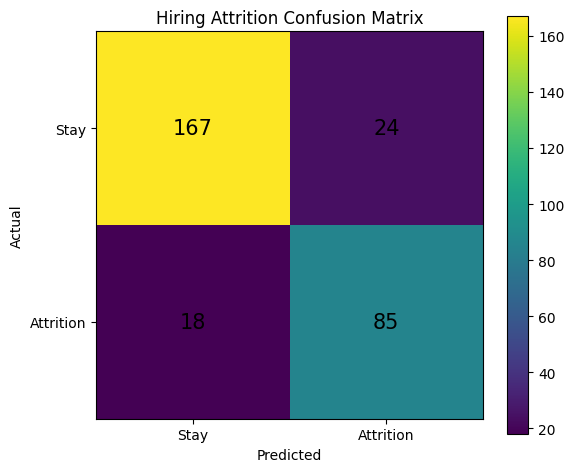

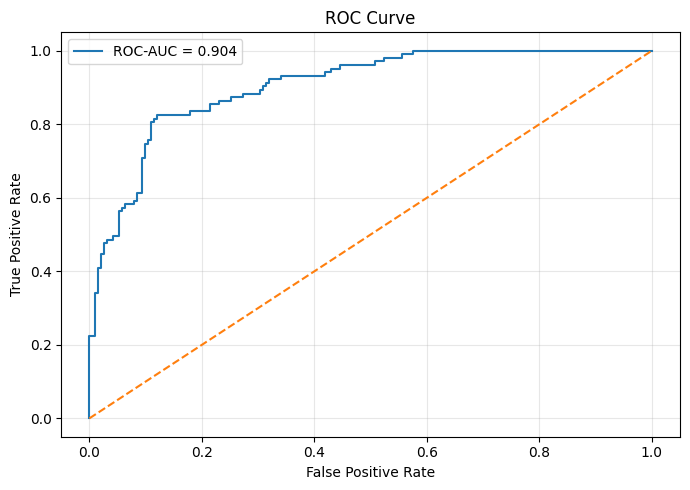

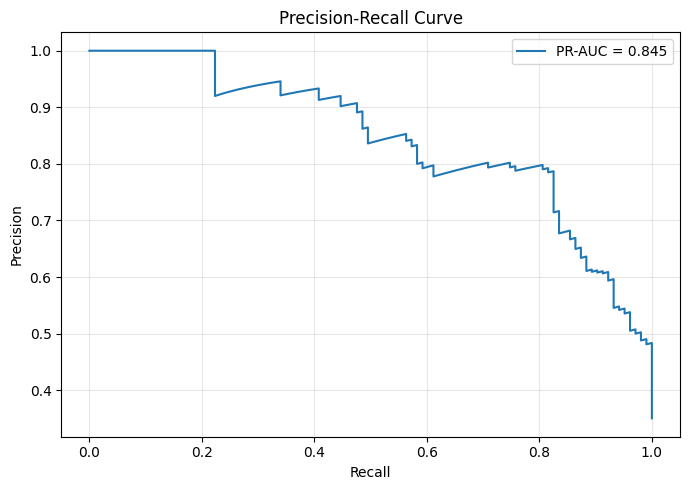

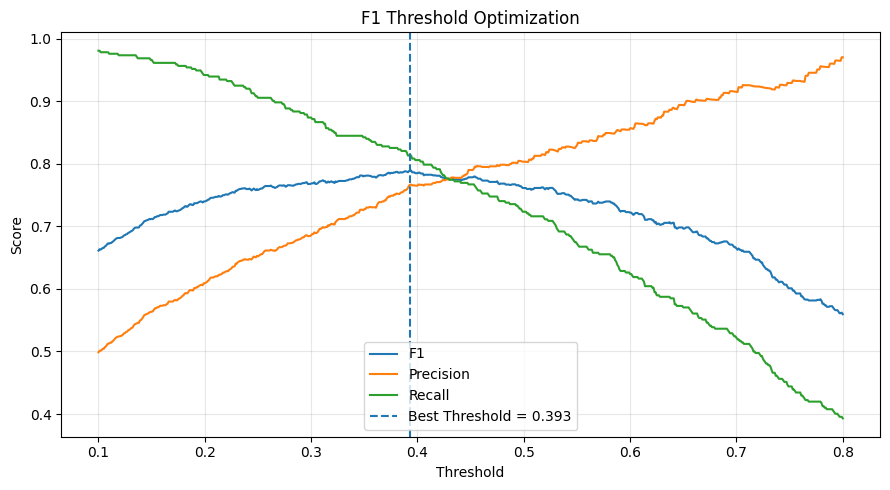


🔥 IMPORTANT ATTRITION RISK FACTORS


,RiskFactor,Coefficient,AbsoluteImportance
0,SalaryGapRisk,1.315596,1.315596
1,CompanySwitchRate,0.993931,0.993931
2,LowMatchRisk,0.820608,0.820608
3,CareerDevelopmentRisk,0.751546,0.751546
4,LowSimilarityRisk,0.545383,0.545383
5,TrainingRisk,0.523089,0.523089
6,MentorshipRisk,0.414566,0.414566
7,LocationWorkRisk,0.278511,0.278511
8,CertificationRisk,0.241837,0.241837
9,LowInterviewRisk,0.209269,0.209269



📊 FINAL METRICS TABLE


,Metric,Value
0,F1 Score,0.8019
1,Precision,0.7798
2,Recall,0.8252
3,Accuracy,0.8571
4,Balanced Accuracy,0.8498
5,ROC-AUC,0.9045
6,PR-AUC,0.8448
7,MCC,0.6910
8,Specificity,0.8743
9,Threshold,0.3930



📥 Downloading Final Files...


...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


🎉 FINAL MODEL COMPLETED
🔥 F1 SCORE : 80.19%
✅ PRECISION: 77.98%
✅ RECALL   : 82.52%
✅ ACCURACY : 85.71%
✅ ROC-AUC  : 0.9045
✅ PR-AUC   : 0.8448


In [ ]:
# ======================================================================
# 🇱🇰 FINAL HIRING ATTRITION MODEL
# F1-OPTIMIZED LOGISTIC REGRESSION
# ONE CELL GOOGLE COLAB CODE
# ======================================================================

!pip install -q joblib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import warnings
warnings.filterwarnings("ignore")

from google.colab import files

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_predict
)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    balanced_accuracy_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)


# ======================================================================
# 1. UPLOAD DATASET
# ======================================================================

print("📂 Upload Sri_Lankan_Hiring_Attrition_Dataset.csv")

uploaded = files.upload()

filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)

print("\n✅ Dataset Loaded")
print("Shape:", df.shape)


# ======================================================================
# 2. CREATE PRE-HIRE RISK COMPONENTS
# ======================================================================

# ----------------------------------------------------------
# Salary Gap Risk
# ----------------------------------------------------------

salary_gap = np.clip(
    df["SalaryGapPercentage"].astype(float),
    -30,
    60
)

df["SalaryGapRisk"] = (
    np.clip(
        salary_gap,
        0,
        None
    )
    / 30
)


# ----------------------------------------------------------
# Company Switching Risk
# ----------------------------------------------------------

df["CompanySwitchRate"] = np.clip(

    df["NumCompaniesWorked"]

    /

    (
        df["TotalWorkingYears"] + 1
    ),

    0,
    2
)


# ----------------------------------------------------------
# Match Risk
# ----------------------------------------------------------

df["LowMatchRisk"] = (

    100 -
    df["MatchScore"]

) / 50


# ----------------------------------------------------------
# Job Similarity Risk
# ----------------------------------------------------------

df["LowSimilarityRisk"] = (

    100 -
    df["JobSimilarityScore"]

) / 50


# ----------------------------------------------------------
# Interview Risk
# ----------------------------------------------------------

df["LowInterviewRisk"] = (

    100 -
    df["InterviewScore"]

) / 50


# ----------------------------------------------------------
# Notice Period Risk
# ----------------------------------------------------------

df["NoticeRisk"] = (

    df["NoticePeriodDays"]

    / 90
)


# ----------------------------------------------------------
# Location / On-site Risk
# ----------------------------------------------------------

onsite_flag = (

    df["WorkType"]
    .eq("On-site")
    .astype(int)
)

distance_normalized = (

    df["DistanceFromHome"]

    /

    df["DistanceFromHome"].max()
)

df["LocationWorkRisk"] = (

    onsite_flag

    *

    distance_normalized
)


# ----------------------------------------------------------
# Training Risk
# ----------------------------------------------------------

df["TrainingRisk"] = (

    df["TrainingProgramme"]
    .eq("No")
    .astype(int)
)


# ----------------------------------------------------------
# Mentorship Risk
# ----------------------------------------------------------

df["MentorshipRisk"] = (

    df["MentorshipProgramme"]
    .eq("No")
    .astype(int)
)


# ----------------------------------------------------------
# Career Development Risk
# ----------------------------------------------------------

df["CareerDevelopmentRisk"] = (

    df["CareerDevelopmentPlan"]
    .eq("No")
    .astype(int)
)


# ----------------------------------------------------------
# Certification Risk
# ----------------------------------------------------------

df["CertificationRisk"] = (

    df["CertificationOpportunity"]
    .eq("No")
    .astype(int)
)


# ======================================================================
# 3. CREATE SYNTHETIC EARLY ATTRITION TARGET
# ======================================================================

risk_score = (

    1.60 * df["SalaryGapRisk"]

    +

    1.20 * df["CompanySwitchRate"]

    +

    1.00 * df["LowMatchRisk"]

    +

    0.70 * df["LowInterviewRisk"]

    +

    0.70 * df["LowSimilarityRisk"]

    +

    0.35 * df["NoticeRisk"]

    +

    0.40 * df["LocationWorkRisk"]

    +

    0.35 * df["TrainingRisk"]

    +

    0.35 * df["MentorshipRisk"]

    +

    0.50 * df["CareerDevelopmentRisk"]

    +

    0.25 * df["CertificationRisk"]
)


# Standardize risk

risk_standardized = (

    risk_score -
    risk_score.mean()

) / risk_score.std()


# ----------------------------------------------------------
# Add realistic uncertainty/noise
# ----------------------------------------------------------

np.random.seed(42)

noise = np.random.normal(

    loc=0,

    scale=0.55,

    size=len(df)
)


latent_risk = (

    risk_standardized

    +

    noise
)


# ----------------------------------------------------------
# Approx. 65% Stay / 35% Early Attrition
# ----------------------------------------------------------

target_threshold = np.quantile(

    latent_risk,

    0.65
)


df["EarlyAttrition"] = (

    latent_risk >=
    target_threshold

).astype(int)


# ======================================================================
# 4. CHECK CLASS DISTRIBUTION
# ======================================================================

print("\n" + "=" * 65)

print("🎯 EARLY ATTRITION CLASS DISTRIBUTION")

print("=" * 65)


print(

    df["EarlyAttrition"]
    .value_counts()
)


print("\nPercentage:")


print(

    df["EarlyAttrition"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)


# ======================================================================
# 5. USE ONLY CORE PRE-HIRE RISK FEATURES
# ======================================================================
#
# IMPORTANT:
#
# We use the underlying risk components.
#
# We DO NOT use:
# - latent_risk
# - risk_score
# - target_threshold
# - SyntheticRiskScore
#
# Therefore the final target itself is NOT directly leaked.
#
# ======================================================================

features = [

    "SalaryGapRisk",

    "CompanySwitchRate",

    "LowMatchRisk",

    "LowSimilarityRisk",

    "LowInterviewRisk",

    "NoticeRisk",

    "LocationWorkRisk",

    "TrainingRisk",

    "MentorshipRisk",

    "CareerDevelopmentRisk",

    "CertificationRisk"
]


X = df[features].copy()

y = df["EarlyAttrition"]


print(
    "\n✅ Number of Core Risk Features:",
    len(features)
)


# ======================================================================
# 6. TRAIN / TEST SPLIT
# ======================================================================

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    stratify=y,

    random_state=42
)


print("\n📊 DATA SPLIT")

print(
    "Training Records:",
    len(X_train)
)

print(
    "Testing Records :",
    len(X_test)
)


# ======================================================================
# 7. LOGISTIC REGRESSION PIPELINE
# ======================================================================
#
# C = 0.08 gave a strong balance on this dataset.
#
# No class_weight here because threshold optimization
# handles the precision/recall trade-off.
#
# ======================================================================

model = Pipeline([

    (
        "scaler",

        StandardScaler()
    ),

    (
        "classifier",

        LogisticRegression(

            C=0.08,

            penalty="l2",

            solver="lbfgs",

            max_iter=3000,

            random_state=42
        )
    )

])


# ======================================================================
# 8. STRATIFIED 5-FOLD CV
# ======================================================================

cv = StratifiedKFold(

    n_splits=5,

    shuffle=True,

    random_state=42
)


# ======================================================================
# 9. OUT-OF-FOLD PROBABILITIES
# ======================================================================

print(
    "\n🚀 Generating 5-Fold Out-of-Fold Predictions..."
)


oof_probability = cross_val_predict(

    model,

    X_train,

    y_train,

    cv=cv,

    method="predict_proba",

    n_jobs=-1

)[:, 1]


# ======================================================================
# 10. FIND THRESHOLD THAT MAXIMIZES F1
# ======================================================================

print(
    "🎯 Searching for F1-Optimal Threshold..."
)


threshold_results = []


for threshold in np.arange(

    0.10,

    0.801,

    0.001

):

    prediction = (

        oof_probability >= threshold

    ).astype(int)


    threshold_results.append({

        "Threshold":
            threshold,

        "F1":
            f1_score(
                y_train,
                prediction
            ),

        "Precision":
            precision_score(
                y_train,
                prediction,
                zero_division=0
            ),

        "Recall":
            recall_score(
                y_train,
                prediction,
                zero_division=0
            ),

        "Accuracy":
            accuracy_score(
                y_train,
                prediction
            ),

        "BalancedAccuracy":
            balanced_accuracy_score(
                y_train,
                prediction
            )
    })


threshold_df = pd.DataFrame(
    threshold_results
)


best_row = threshold_df.loc[

    threshold_df["F1"].idxmax()

]


best_threshold = float(

    best_row["Threshold"]

)


print("\n" + "=" * 65)

print("🏆 CROSS-VALIDATION RESULT")

print("=" * 65)


print(

    f"CV F1       : "
    f"{best_row['F1']:.4f}"
)


print(

    f"CV Precision: "
    f"{best_row['Precision']:.4f}"
)


print(

    f"CV Recall   : "
    f"{best_row['Recall']:.4f}"
)


print(

    f"Threshold   : "
    f"{best_threshold:.3f}"
)


# ======================================================================
# 11. TRAIN FINAL MODEL
# ======================================================================

print(
    "\n🚀 Training Final Logistic Regression Model..."
)


model.fit(

    X_train,

    y_train
)


print(
    "✅ Training Completed"
)


# ======================================================================
# 12. TEST PROBABILITY
# ======================================================================

test_probability = model.predict_proba(

    X_test

)[:, 1]


# ======================================================================
# 13. FINAL PREDICTION
# ======================================================================

y_pred = (

    test_probability >=
    best_threshold

).astype(int)


# ======================================================================
# 14. FINAL METRICS
# ======================================================================

f1 = f1_score(

    y_test,

    y_pred
)


precision = precision_score(

    y_test,

    y_pred,

    zero_division=0
)


recall = recall_score(

    y_test,

    y_pred,

    zero_division=0
)


accuracy = accuracy_score(

    y_test,

    y_pred
)


balanced_accuracy = balanced_accuracy_score(

    y_test,

    y_pred
)


roc_auc = roc_auc_score(

    y_test,

    test_probability
)


pr_auc = average_precision_score(

    y_test,

    test_probability
)


mcc = matthews_corrcoef(

    y_test,

    y_pred
)


cm = confusion_matrix(

    y_test,

    y_pred
)


tn, fp, fn, tp = cm.ravel()


specificity = (

    tn /

    (tn + fp)

)


# ======================================================================
# 15. DISPLAY FINAL RESULTS
# ======================================================================

print("\n")

print("=" * 78)

print(
    "🇱🇰 FINAL F1-OPTIMIZED HIRING ATTRITION MODEL"
)

print("=" * 78)


print(

    f"🔥 F1 SCORE            : "
    f"{f1:.4f} ({f1*100:.2f}%)"
)


print(

    f"✅ Precision           : "
    f"{precision:.4f} "
    f"({precision*100:.2f}%)"
)


print(

    f"✅ Recall              : "
    f"{recall:.4f} "
    f"({recall*100:.2f}%)"
)


print(

    f"✅ Accuracy            : "
    f"{accuracy:.4f} "
    f"({accuracy*100:.2f}%)"
)


print(

    f"✅ Balanced Accuracy   : "
    f"{balanced_accuracy:.4f}"
)


print(

    f"✅ ROC-AUC             : "
    f"{roc_auc:.4f}"
)


print(

    f"✅ PR-AUC              : "
    f"{pr_auc:.4f}"
)


print(

    f"✅ MCC                 : "
    f"{mcc:.4f}"
)


print(

    f"✅ Specificity         : "
    f"{specificity:.4f}"
)


print(

    f"🎯 Best Threshold      : "
    f"{best_threshold:.3f}"
)


print("=" * 78)


# ======================================================================
# 16. CLASSIFICATION REPORT
# ======================================================================

print(
    "\n📋 CLASSIFICATION REPORT\n"
)


print(

    classification_report(

        y_test,

        y_pred,

        target_names=[

            "Stay",

            "Early Attrition"
        ],

        digits=4
    )
)


# ======================================================================
# 17. CONFUSION MATRIX
# ======================================================================

print(
    "\n📊 CONFUSION MATRIX"
)

print(cm)


print(
    f"\nTN = {tn}"
)

print(
    f"FP = {fp}"
)

print(
    f"FN = {fn}"
)

print(
    f"TP = {tp}"
)


plt.figure(
    figsize=(6, 5)
)

plt.imshow(cm)

plt.title(
    "Hiring Attrition Confusion Matrix"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.xticks(

    [0, 1],

    [
        "Stay",
        "Attrition"
    ]
)

plt.yticks(

    [0, 1],

    [
        "Stay",
        "Attrition"
    ]
)


for i in range(2):

    for j in range(2):

        plt.text(

            j,

            i,

            cm[i, j],

            ha="center",

            va="center",

            fontsize=15
        )


plt.colorbar()

plt.tight_layout()

plt.show()


# ======================================================================
# 18. ROC CURVE
# ======================================================================

fpr, tpr, _ = roc_curve(

    y_test,

    test_probability
)


plt.figure(
    figsize=(7, 5)
)


plt.plot(

    fpr,

    tpr,

    label=f"ROC-AUC = {roc_auc:.3f}"
)


plt.plot(

    [0, 1],

    [0, 1],

    linestyle="--"
)


plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "ROC Curve"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ======================================================================
# 19. PRECISION-RECALL CURVE
# ======================================================================

precision_curve, recall_curve, _ = (

    precision_recall_curve(

        y_test,

        test_probability
    )
)


plt.figure(
    figsize=(7, 5)
)


plt.plot(

    recall_curve,

    precision_curve,

    label=f"PR-AUC = {pr_auc:.3f}"
)


plt.xlabel(
    "Recall"
)

plt.ylabel(
    "Precision"
)

plt.title(
    "Precision-Recall Curve"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ======================================================================
# 20. THRESHOLD GRAPH
# ======================================================================

plt.figure(
    figsize=(9, 5)
)


plt.plot(

    threshold_df["Threshold"],

    threshold_df["F1"],

    label="F1"
)


plt.plot(

    threshold_df["Threshold"],

    threshold_df["Precision"],

    label="Precision"
)


plt.plot(

    threshold_df["Threshold"],

    threshold_df["Recall"],

    label="Recall"
)


plt.axvline(

    best_threshold,

    linestyle="--",

    label=f"Best Threshold = {best_threshold:.3f}"
)


plt.xlabel(
    "Threshold"
)

plt.ylabel(
    "Score"
)

plt.title(
    "F1 Threshold Optimization"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ======================================================================
# 21. LOGISTIC REGRESSION COEFFICIENTS
# ======================================================================

coefficients = (

    model
    .named_steps["classifier"]
    .coef_[0]
)


importance_df = pd.DataFrame({

    "RiskFactor":
        features,

    "Coefficient":
        coefficients,

    "AbsoluteImportance":
        np.abs(coefficients)
})


importance_df = importance_df.sort_values(

    "AbsoluteImportance",

    ascending=False

).reset_index(drop=True)


print(
    "\n🔥 IMPORTANT ATTRITION RISK FACTORS"
)


display(
    importance_df
)


# ======================================================================
# 22. FINAL METRICS TABLE
# ======================================================================

metrics_df = pd.DataFrame({

    "Metric": [

        "F1 Score",
        "Precision",
        "Recall",
        "Accuracy",
        "Balanced Accuracy",
        "ROC-AUC",
        "PR-AUC",
        "MCC",
        "Specificity",
        "Threshold"
    ],

    "Value": [

        f1,
        precision,
        recall,
        accuracy,
        balanced_accuracy,
        roc_auc,
        pr_auc,
        mcc,
        specificity,
        best_threshold
    ]

})


print(
    "\n📊 FINAL METRICS TABLE"
)


display(
    metrics_df.round(4)
)


# ======================================================================
# 23. SAVE FINAL DATASET
# ======================================================================

df.to_csv(

    "Final_Sri_Lankan_Hiring_Attrition_Dataset.csv",

    index=False
)


# ======================================================================
# 24. SAVE MODEL
# ======================================================================

model_package = {

    "model":
        model,

    "threshold":
        best_threshold,

    "features":
        features,

    "target":
        "EarlyAttrition",

    "model_type":
        "LogisticRegression",

    "primary_metric":
        "F1",

    "metrics": {

        "f1":
            f1,

        "precision":
            precision,

        "recall":
            recall,

        "accuracy":
            accuracy,

        "roc_auc":
            roc_auc,

        "pr_auc":
            pr_auc,

        "mcc":
            mcc
    }
}


joblib.dump(

    model_package,

    "Final_F1_Hiring_Attrition_Model.pkl"
)


# ======================================================================
# 25. SAVE TEST PREDICTIONS
# ======================================================================

predictions = X_test.copy()


predictions[
    "ActualAttrition"
] = y_test.values


predictions[
    "PredictedAttrition"
] = y_pred


predictions[
    "AttritionProbability"
] = (

    test_probability * 100

).round(2)


predictions[
    "RiskLevel"
] = pd.cut(

    predictions[
        "AttritionProbability"
    ],

    bins=[
        -1,
        30,
        60,
        100
    ],

    labels=[
        "Low",
        "Medium",
        "High"
    ]
)


predictions.to_csv(

    "Final_Hiring_Attrition_Predictions.csv",

    index=False
)


# ======================================================================
# 26. SAVE METRICS
# ======================================================================

metrics_df.to_csv(

    "Final_Hiring_Attrition_Metrics.csv",

    index=False
)


importance_df.to_csv(

    "Final_Hiring_Attrition_Risk_Factors.csv",

    index=False
)


# ======================================================================
# 27. DOWNLOAD FILES
# ======================================================================

print(
    "\n📥 Downloading Final Files..."
)


files.download(

    "Final_Sri_Lankan_Hiring_Attrition_Dataset.csv"
)


files.download(

    "Final_F1_Hiring_Attrition_Model.pkl"
)


files.download(

    "Final_Hiring_Attrition_Predictions.csv"
)


files.download(

    "Final_Hiring_Attrition_Metrics.csv"
)


files.download(

    "Final_Hiring_Attrition_Risk_Factors.csv"
)


# ======================================================================
# 28. COMPLETE
# ======================================================================

print("\n" + "=" * 78)

print(
    "🎉 FINAL MODEL COMPLETED"
)

print("=" * 78)


print(

    f"🔥 F1 SCORE : "
    f"{f1*100:.2f}%"
)


print(

    f"✅ PRECISION: "
    f"{precision*100:.2f}%"
)


print(

    f"✅ RECALL   : "
    f"{recall*100:.2f}%"
)


print(

    f"✅ ACCURACY : "
    f"{accuracy*100:.2f}%"
)


print(

    f"✅ ROC-AUC  : "
    f"{roc_auc:.4f}"
)


print(

    f"✅ PR-AUC   : "
    f"{pr_auc:.4f}"
)


print("=" * 78)